# Exercise 1

In [ ]:
import autograd.numpy as np
datapath = './'

csvname = datapath + 'breast_cancer_data.csv'
data1 = np.loadtxt(csvname,delimiter = ',')

x = data1[:-1,:]
y = data1[-1:,:] 

In [4]:
# compute linear combination of input points
def model(x,w):
    a = w[0] + np.dot(x.T,w[1:])
    return a.T

# an implementation of the softmax cost
def softmax(w):    
    # compute the least squares cost
    cost = np.sum(np.log(1 + np.exp(-y*model(x,w))))
    return cost/float(np.size(y))

# an implementation of the perceptron cost
def perceptron(w):
    cost = np.sum(np.maximum(0, -y*model(x,w)))
    return cost/float(np.size(y))

In [5]:
import autograd.numpy as np
from autograd import grad

def gradient_descent(g,alpha,max_its,w):
    gradient = grad(g)
    weight_history = [w]
    cost_history = [g(w)]
    for k in range(max_its):
        grad_eval = gradient(w)
        w = w - alpha*grad_eval
        weight_history.append(w)
        cost_history.append(g(w))
    return cost_history,weight_history

max_its = 1000
w = 0.1*np.random.randn(9,1)

# Perceptron cost function
cost_history_perceptron, weight_history_perceptron = gradient_descent(perceptron, 0.1, max_its, w)

# Softmax cost function
cost_history_softmax, weight_history_softmax = gradient_descent(softmax, 1.0, max_its, w)


In [ ]:

def miscount(w,x,y):
    a = model(x,w)

    y_predict = np.sign(a)
   
    y_predict[y_predict == 0] = 1
    
    misclassifications = np.sum(y_predict != y)
    return misclassifications

In [7]:
miscount_history_perceptron = [miscount(v,x,y) for v in weight_history_perceptron]
miscount_history_softmax = [miscount(v,x,y) for v in weight_history_softmax]


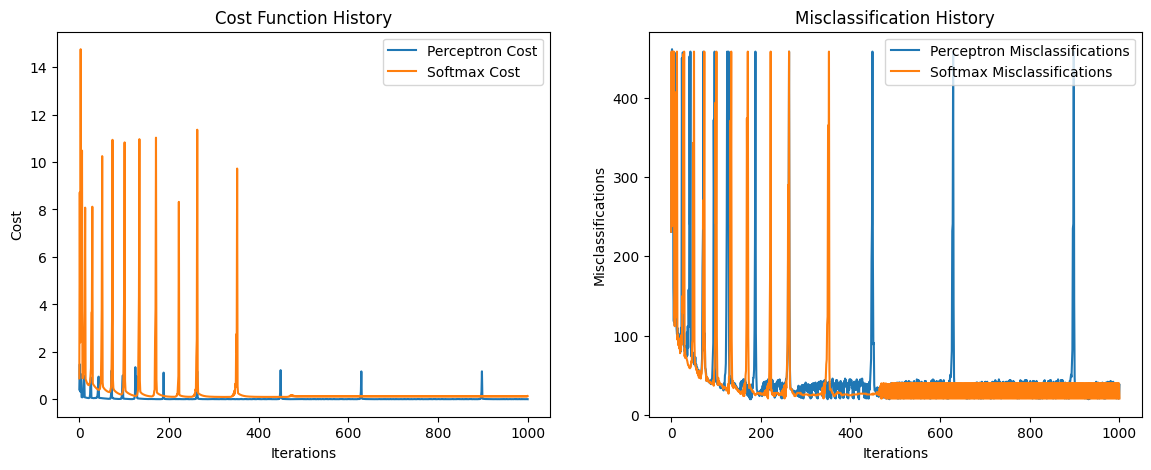

In [8]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(cost_history_perceptron, label='Perceptron Cost')
ax1.plot(cost_history_softmax, label='Softmax Cost')
ax1.set_title('Cost Function History')
ax1.set_xlabel('Iterations')
ax1.set_ylabel('Cost')
ax1.legend()

ax2.plot(miscount_history_perceptron, label='Perceptron Misclassifications')
ax2.plot(miscount_history_softmax, label='Softmax Misclassifications')
ax2.set_title('Misclassification History')
ax2.set_xlabel('Iterations')
ax2.set_ylabel('Misclassifications')
ax2.legend()

plt.show()

In [9]:
min_miscounts_perceptron = np.min(miscount_history_perceptron)
min_miscounts_softmax = np.min(miscount_history_softmax)

print(f"Minimum misclassifications (Perceptron): {min_miscounts_perceptron}")
print(f"Minimum misclassifications (Softmax): {min_miscounts_softmax}")

Minimum misclassifications (Perceptron): 20
Minimum misclassifications (Softmax): 21


In [10]:
def miscount_malignant(w,x,y):
    a = model(x,w)
    y_predict = np.sign(a)
    y_predict[y_predict == 0] = 1
    # find indices where true label is malignant (-1)
    malignant_indices = np.argwhere(y == -1)[:, 1]
    
    y_true_malignant = y[0, malignant_indices]
    y_pred_malignant = y_predict[0, malignant_indices]
    
    misclassifications = np.sum(y_pred_malignant != y_true_malignant)
    return misclassifications

miscount_malignant_history_p = [miscount_malignant(v,x,y) for v in weight_history_perceptron]
miscount_malignant_history_s = [miscount_malignant(v,x,y) for v in weight_history_softmax]
print(f"Minimum malignant misclassifications (Perceptron): {np.min(miscount_malignant_history_p)}")
print(f"Minimum malignant misclassifications (Softmax): {np.min(miscount_malignant_history_s)}")

Minimum malignant misclassifications (Perceptron): 0
Minimum malignant misclassifications (Softmax): 0


### 1.5 Logistic Regression with Cross Entropy Cost

In [13]:
a=np.argwhere(y>0.9)
b=np.argwhere(y<-0.9)
yc=np.arange(699)
yc[a]=1
yc[b]=0

def sigmoid(t):
    return 1/(1 + np.exp(-t))

lam = 2*10**(-3)
def cross_entropy(w):
    a = sigmoid(model(x,w))
    ind = np.argwhere(yc == 0)
    cost = -np.sum(np.log(1 - a[:,ind]))
    ind = np.argwhere(yc==1)
    cost -= np.sum(np.log(a[:,ind]))
    cost += lam*np.sum(w[1:]**2)
    return cost/float(np.size(yc))


In [14]:
alpha_logistic = 0.6
max_its = 1000
w_logistic = 0.1*np.random.randn(9,1)

cost_history_logistic, weight_history_logistic = gradient_descent(cross_entropy, alpha_logistic, max_its, w_logistic)


In [15]:
def miscount_logistic(w,x,yc):
    a = sigmoid(model(x,w))
    # predict 1 if sigmoid > 0.5, else 0
    y_predict = np.where(a > 0.5, 1, 0)
    misclassifications = np.sum(y_predict != yc)
    return misclassifications

miscount_history_logistic = [miscount_logistic(v,x,yc) for v in weight_history_logistic]

print(f"Minimum misclassifications (Logistic / Cross Entropy): {np.min(miscount_history_logistic)}")


Minimum misclassifications (Logistic / Cross Entropy): 22


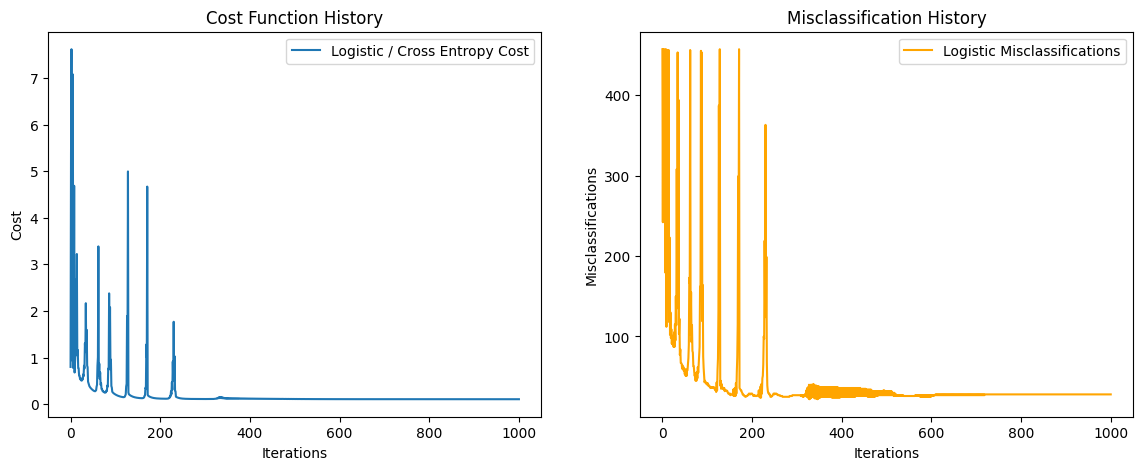

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(cost_history_logistic, label='Logistic / Cross Entropy Cost')
ax1.set_title('Cost Function History')
ax1.set_xlabel('Iterations')
ax1.set_ylabel('Cost')
ax1.legend()

ax2.plot(miscount_history_logistic, label='Logistic Misclassifications', color='orange')
ax2.set_title('Misclassification History')
ax2.set_xlabel('Iterations')
ax2.set_ylabel('Misclassifications')
ax2.legend()

plt.show()

In [17]:
# define sigmoid function
def sigmoid(t):
    return 1/(1 + np.exp(-t))

# the convex cross-entropy cost function
lam = 2*10**(-3)
def cross_entropy(w):
    # compute sigmoid of model
    a = sigmoid(model(x,w))

    # compute cost of label 0 points
    ind = np.argwhere(yc == 0)
    cost = -np.sum(np.log(1 - a[:,ind]))

    # add cost on label 1 points
    ind = np.argwhere(yc==1)
    cost -= np.sum(np.log(a[:,ind]))

    # add regularizer
    cost += lam*np.sum(w[1:]**2)

    # compute cross-entropy
    return cost/float(np.size(yc))

# Exercise 2

In [19]:
import pandas as pd

df = pd.read_csv('spambase_data.csv', header=None)
data2 = df.to_numpy()

x2 = data2[:-1,:]
y2 = data2[-1:,:]

def model2(x,w):
    a = w[0] + np.dot(x.T,w[1:])
    return a.T

def softmax2(w):    
    cost = np.sum(np.log(1 + np.exp(-y2*model2(x2,w))))
    return cost/float(np.size(y2))

def perceptron2(w):
    cost = np.sum(np.maximum(0, -y2*model2(x2,w)))
    return cost/float(np.size(y2))

def standard_normalizer(x):
    x_means = np.nanmean(x,axis = 1)[:,np.newaxis]
    x_stds = np.nanstd(x,axis = 1)[:,np.newaxis]
    ind = np.argwhere(x_stds < 10**(-2))
    if len(ind) > 0:
        ind = [v[0] for v in ind] 
        adjust = np.zeros((x_stds.shape))
        adjust[ind] = 1.0
        x_stds += adjust
    ind = np.argwhere(np.isnan(x) == True)
    for i in ind:
        x[i[0],i[1]] = x_means[i[0]]
    normalizer = lambda data: (data - x_means)/x_stds
    inverse_normalizer = lambda data: data*x_stds + x_means
    return normalizer,inverse_normalizer

normalizer, inverse_normalizer = standard_normalizer(x2)
x2 = normalizer(x2)


In [20]:
N = np.shape(x2)[0]
max_its = 1000
w2 = 0.1*np.random.randn(N+1,1)

cost_history_perceptron2, weight_history_perceptron2 = gradient_descent(perceptron2, 0.1, max_its, w2)
cost_history_softmax2, weight_history_softmax2 = gradient_descent(softmax2, 1.0, max_its, w2)


In [21]:
def miscount2(w,x,y):
    a = model2(x,w)
    y_predict = np.sign(a)
    y_predict[y_predict == 0] = 1
    misclassifications = np.sum(y_predict != y)
    return misclassifications

miscount_history_p2 = [miscount2(v,x2,y2) for v in weight_history_perceptron2]
miscount_history_s2 = [miscount2(v,x2,y2) for v in weight_history_softmax2]


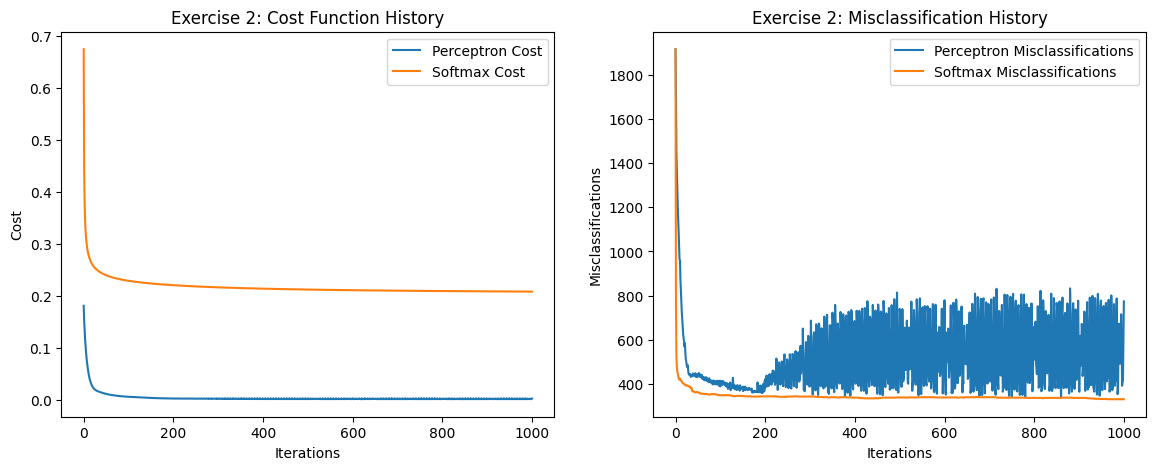

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(cost_history_perceptron2, label='Perceptron Cost')
ax1.plot(cost_history_softmax2, label='Softmax Cost')
ax1.set_title('Exercise 2: Cost Function History')
ax1.set_xlabel('Iterations')
ax1.set_ylabel('Cost')
ax1.legend()

ax2.plot(miscount_history_p2, label='Perceptron Misclassifications')
ax2.plot(miscount_history_s2, label='Softmax Misclassifications')
ax2.set_title('Exercise 2: Misclassification History')
ax2.set_xlabel('Iterations')
ax2.set_ylabel('Misclassifications')
ax2.legend()

plt.show()

### 2.2 Accuracies

In [26]:
min_miscounts_p2 = np.min(miscount_history_p2)
min_miscounts_s2 = np.min(miscount_history_s2)

total_samples = np.size(y2)

accuracy_p2 = (total_samples - min_miscounts_p2) / total_samples * 100
accuracy_s2 = (total_samples - min_miscounts_s2) / total_samples * 100

print(f"Perceptron: {min_miscounts_p2} minimum misclassifications  ({accuracy_p2:.2f}% accuracy)")
print(f"Softmax: {min_miscounts_s2} minimum misclassifications  ({accuracy_s2:.2f}% accuracy)")


Perceptron: 337 minimum misclassifications  (92.68% accuracy)
Softmax: 331 minimum misclassifications  (92.81% accuracy)


### 2.3 Confusion Matrix for Softmax

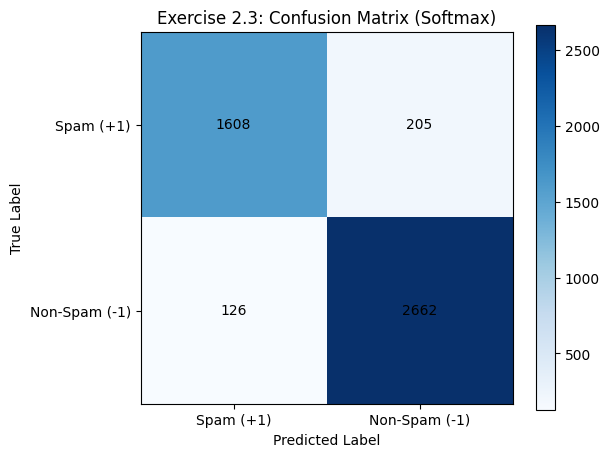

In [28]:
# Find the best w for softmax based on the iteration with the lowest misclassifications
best_ind = np.argmin(miscount_history_s2)
best_w = weight_history_softmax2[best_ind]

# Predict using the best w
a = model2(x2, best_w)
y_predict = np.sign(a)
y_predict[y_predict == 0] = 1

y_true = y2.flatten()
y_pred = y_predict.flatten()

# Compute Confusion Matrix Elements
TP = np.sum((y_pred == 1) & (y_true == 1))
TN = np.sum((y_pred == -1) & (y_true == -1))
FP = np.sum((y_pred == 1) & (y_true == -1))
FN = np.sum((y_pred == -1) & (y_true == 1))
import matplotlib.pyplot as plt

cm = np.array([[TP, FN], [FP, TN]])
labels = ['Spam (+1)', 'Non-Spam (-1)']

fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.imshow(cm, cmap='Blues')
plt.colorbar(cax)

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        text = ax.text(j, i, cm[i, j], ha='center', va='center', color='black')

ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Exercise 2.3: Confusion Matrix (Softmax)')
plt.show()


In [24]:
# standard normalization function - with nan checker / filler in-er
def standard_normalizer(x):    
    # compute the mean and standard deviation of the input
    x_means = np.nanmean(x,axis = 1)[:,np.newaxis]
    x_stds = np.nanstd(x,axis = 1)[:,np.newaxis]   

    # check to make sure that x_stds > small threshold, for those not
    # divide by 1 instead of original standard deviation
    ind = np.argwhere(x_stds < 10**(-2))
    if len(ind) > 0:
        ind = [v[0] for v in ind] # Just keep the row index
        adjust = np.zeros((x_stds.shape))
        adjust[ind] = 1.0
        x_stds += adjust

    # fill in any nan values with means 
    ind = np.argwhere(np.isnan(x) == True)
    for i in ind:
        x[i[0],i[1]] = x_means[i[0]]

    # create standard normalizer function
    normalizer = lambda data: (data - x_means)/x_stds

    # create inverse standard normalizer
    inverse_normalizer = lambda data: data*x_stds + x_means

    # return normalizer 
    return normalizer,inverse_normalizer

In [25]:
# data input
csvname = datapath + 'spambase_data.csv'
data = np.loadtxt(csvname,delimiter = ',')

# get input and output of dataset
x = data[:-1,:]
y = data[-1:,:] 
normalizer,inverse_normalizer = standard_normalizer(x)
x = normalizer(x)

# Exercise 3

In [ ]:
# load in dataset
csvname = datapath + 'credit_dataset.csv'
data = np.loadtxt(csvname,delimiter = ',')
x = data[:-1,:]
y = data[-1:,:]

# Exercise 4

In [ ]:
# compute C linear combinations of input point, one per classifier
def model(x,w):
    a = w[0] + np.dot(x.T,w[1:])
    return a.T

lam = 10**-5  # our regularization paramter 
def multiclass_perceptron(w):        
    # pre-compute predictions on all points
    all_evals = model(x,w)
    
    # compute maximum across data points
    a = np.max(all_evals,axis = 0)    

    # compute cost in compact form using numpy broadcasting
    b = all_evals[y.astype(int).flatten(),np.arange(np.size(y))]
    cost = np.sum(a - b)
    
    # add regularizer
    cost = cost + lam*np.linalg.norm(w[1:,:],'fro')**2
    
    # return average
    return cost/float(np.size(y))

In [ ]:
# load in dataset
data = np.loadtxt(datapath + '3class_data.csv',delimiter = ',')

# get input/output pairs
x = data[:-1,:]
y = data[-1:,:] 